# Computing Initial and Terminal States

## Preliminaries

In this tutorial, you will learn how to use the {class}`~cellrank.estimators.GPCCA` to do the following:

- compute macrostates of cellular dynamics.
- visualize a coarse-grained transition matrix among macrostates.
- classify macrostates as initial, terminal or intermediate.

The {class}`~cellrank.estimators.GPCCA` may be combined with **any** CellRank {mod}`kernel <cellrank.kernels>` used to compute a cell-cell transition matrix, including the {class}`~cellrank.kernels.VelocityKernel`, the {class}`~cellrank.kernels.PseudotimeKernel` and the {class}`~cellrank.kernels.CytoTRACEKernel`. We explain the kernel/estimator paradigm in more detail in our {doc}`../general/100_getting_started` tutorial. 

This tutorial notebook can be downloaded using the following [link](https://github.com/theislab/cellrank_notebooks/blob/main/tutorials/estimators/600_initial_terminal.ipynb).

:::{figure-md} fig-structure

<img src="../_static/img/600_initial_terminal.jpg" width="600" alt="The GPCCA estimator computes initial and terminal states based on Generalized Perron Cluster Cluster Analysis.  ">

**CellRank decomposes cellular dynamics into macrostates:** Based on Generalized Perron Cluster Cluster analysis (GPCCA), CellRank identifies {attr}`~cellrank.estimators.GPCCA.macrostates` of cellular dynamics, which include initial, intermediate, and terminal states {cite}`reuter:18,reuter:19,lange:22`. 
:::

:::{note}

If you want to run this on your own data, you will need:

- a scRNA-seq dataset for which you computed a cell-cell transition matrix using any CellRank {mod}`kernel <cellrank.kernels>`. For each kernel, there exist individual tutorials that teach you how to use them. For example, we have tutorials about using {doc}`RNA velocity <../kernels/200_rna_velocity>`, {doc}`experimental time points <../kernels/500_real_time>`, and {doc}`pseudotime <../kernels/300_pseudotime>`, among others, to derive cell-cell transition probabilities. 

:::

:::{note}

If you encounter any bugs in the code, our if you have suggestions for new features, please open an [issue](https://github.com/theislab/cellrank/issues/new/choose). If you have a general question or something you would like to discuss with us, please post on the [scverse discourse](https://discourse.scverse.org/c/ecosytem/cellrank/40). 

:::

### Import packages & data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

if "google.colab" in sys.modules:
    !pip install -q git+https://github.com/theislab/cellrank

In [3]:
import cellrank as cr
import matplotlib.pyplot as plt
import scanpy as sc
import session_info2

cr.settings.verbosity = 2
sc.set_figure_params(
    frameon=False,
    dpi=100,
)

In [4]:
import warnings

warnings.simplefilter("ignore", category=UserWarning)

To demonstrate the appproach in this tutorial, we will use a scRNA-seq dataset of pancreas development at embyonic day E15.5 {cite}`bastidas-ponce:19`. We used this dataset in our {doc}`CellRank meets RNA velocity tutorial <../kernels/200_rna_velocity>` to compute a cell-cell transition matrix using the {class}`~cellrank.kernels.VelocityKernel`; this tutorial builds on the transition matrix computed there. The dataset including the transition matrix can be conveniently acessed through {mod}`cellrank.datasets.pancreas` {cite}`bastidas-ponce:19, bergen:20`.

In [5]:
adata = cr.datasets.pancreas(kind="preprocessed-kernel")

vk = cr.kernels.VelocityKernel.from_adata(adata, key="T_fwd")
vk

VelocityKernel[n=2531, model='deterministic', similarity='correlation', softmax_scale=4.013]

:::{note}

The method {meth}`~cellrank.kernels.VelocityKernel.from_adata` allows you to reconstruct a CellRank kernel from an {class}`~anndata.AnnData` object. When you use a kernel to compute a transition matrix, this matrix, as well as a few informations about the computation, are written to the underlying {class}`anndata.AnnData` object upon calling {meth}`~cellrank.kernels.VelocityKernel.write_to_adata`. This makes it easy to write and read kernels from disk via the associated {class}`~anndata.AnnData` object. 

:::

As a reminder, below is a UMAP with cluster labels of this dataset {cite}`bastidas-ponce:19, mcinnes:18, becht:19`. In this tutorial, we will automatically identify the initial and terminal states. 

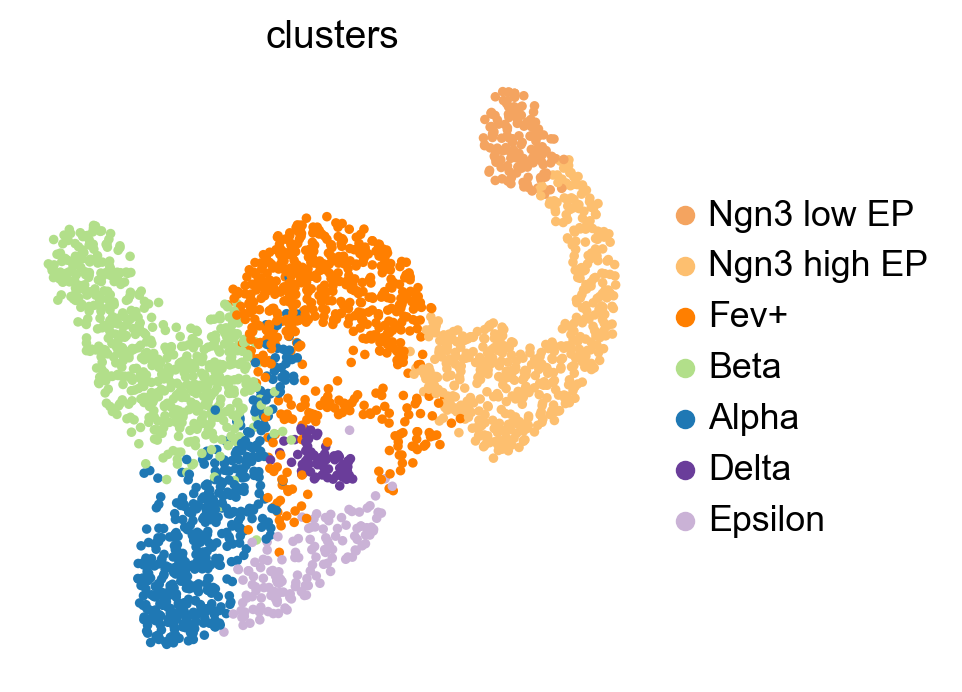

In [6]:
sc.pl.embedding(adata, basis="umap", color="clusters")

## Identify initial and terminal states

### Initialize an estimator 

The {mod}`~cellrank.estimators` allow you to analyze cell-state dynamics in CellRank. We initialize the {class}`GPCCA estimator <cellrank.estimators.GPCCA>` here by passing the {class}`~cellrank.kernels.VelocityKernel` {cite}`reuter:18,reuter:19`. However, the {class}`GPCCA estimator <cellrank.estimators.GPCCA>` works with *every* CellRank {mod}`kernel <cellrank.kernels>`. 

In [7]:
g = cr.estimators.GPCCA(vk)
print(g)

GPCCA[kernel=VelocityKernel[n=2531], initial_states=None, terminal_states=None]


We use the {class}`GPCCA estimator <cellrank.estimators.GPCCA>` below to compute initial & terminal states; it may further be used to compute fate probabilities as we explain in the {doc}`fate probabilities & driver genes tutorial <700_fate_probabilities>`. 

### Compute macrostates

:::{figure-md} fig-gpcca

<img src="../_static/img/600_gpcca_example.jpg" width="1000" alt="The GPCCA estimator computes initial and terminal states based on Generalized Perron Cluster Cluster Analysis.  ">

**Coarse-graining with GPCCA**: Using the GPCCA algorithm, CellRank coarse-grains a cell-cell transition matrix onto the macro-state level. We obtain two key outputs: the soft assignment of cells to {attr}`macrostates <cellrank.estimators.GPCCA.macrostates_memberships>`, and a matrix of transition probabilities among these macrostates {cite}`reuter:18, reuter:19, reuter:22`. 

:::

The computation of macrostates is based on the real [Schur decomposition](https://en.wikipedia.org/wiki/Schur_decomposition) - essentially a generalization of the eigendecomposition. For non-symmetric transition matrices, as in our case, the eigendecomposition in general yields complex eigenvalues and eigenvectors, which are difficult to interpret. Thus, we revert to the real Schur decomposition {cite}`reuter:18,reuter:19`. 

Below, we also plot the real part of the top eigenvalues, sorted by their real part. Blue and orange denote real and complex eigenvalues, respectively. For real matrices, complex eigenvalues always appear in pairs of complex conjugates. 

INFO     Computing Schur decomposition                                                                             
INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                                                              
             Finish (0.71s)                                                                                        


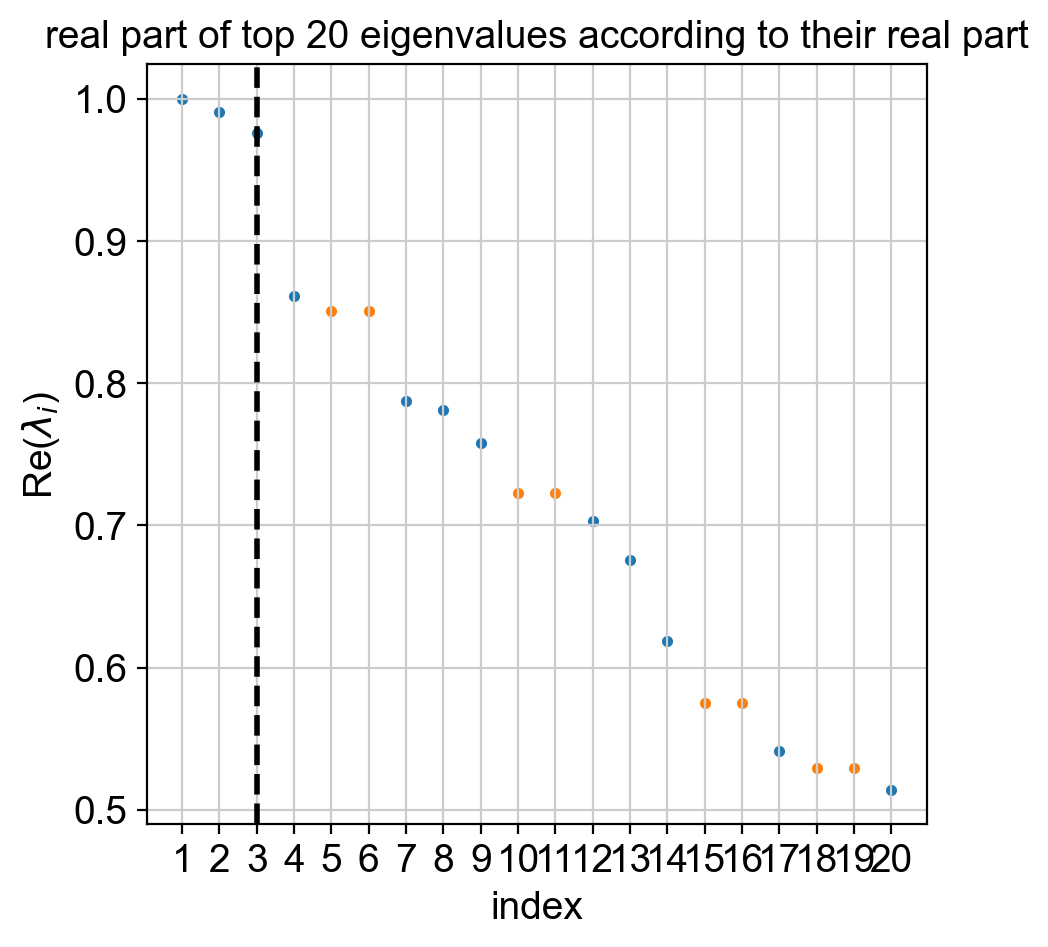

In [8]:
g.compute_schur()
g.plot_spectrum(real_only=True)

Using the {attr}`real Schur decomposition <cellrank.estimators.GPCCA.schur_matrix>`, we compute {attr}`~cellrank.estimators.GPCCA.macrostates` with the GPCCA algorithm as implemented in [pyGPCCA](https://pygpcca.readthedocs.io/en/latest/) by maximizing for metastability {cite}`reuter:18,reuter:19,reuter:22`. {attr}`~cellrank.estimators.GPCCA.macrostates` may contain {attr}`initial <cellrank.estimators.GPCCA.initial_states>`, {attr}`terminal <cellrank.estimators.GPCCA.terminal_states>` and intermediate states of cellular dynamics.  

In the plot above, the estimator automatically suggested a number of states to use (dashed vertical line); however, we will ignore that and compute a few more states to have a chance at identifying the Delta cell population. 

:::{note}

Make sure to have the scientific computing libraries [PETSc](https://petsc.org/release/) and [SLEPc](https://slepc.upv.es/) installed for maximum performance, using e.g. `conda install -c conda-forge petsc4py slepc4py`.  On most machines, this is strongly recommended if your datasets consists of over **10k cells**. See our {doc}`installation instructions <../../../installation>`. 

:::

INFO     Computing 11 macrostates                                                                                  
INFO     Adding `.macrostates`                                                                                     
                `.macrostates_memberships`                                                                         
                `.coarse_T`                                                                                        
                `.coarse_initial_distribution                                                                      
                `.coarse_stationary_distribution`                                                                  
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                   

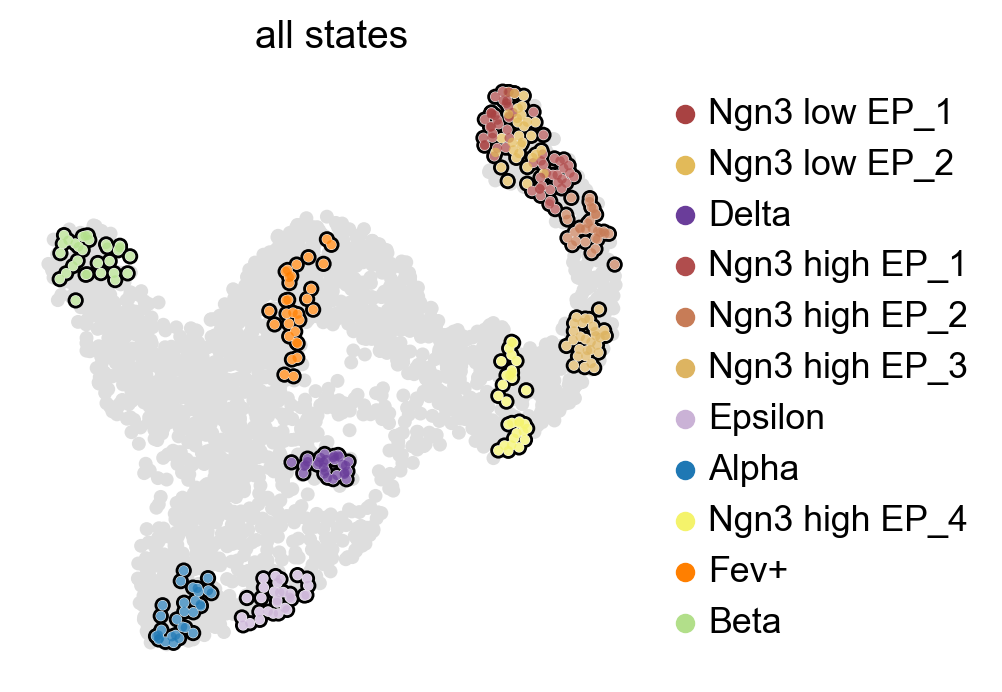

In [9]:
g.compute_macrostates(n_states=11, cluster_key="clusters")
g.plot_macrostates(which="all", legend_loc="right", s=100)

We now have macrostates for Alpha, Beta, Epsilon and Delta populations, besides a few progenitor populations. We assign one label per macrostate based on the underlying `'clusters'` annotation. However, that does not imply that all cells within one macrostate are from the same underlying cluster as we use majority voting. We can visualize the relationship between clusters and macrostates. We show below the distribution over cluster membership for each of the cells most confidently assigned to a certain macrostate. 

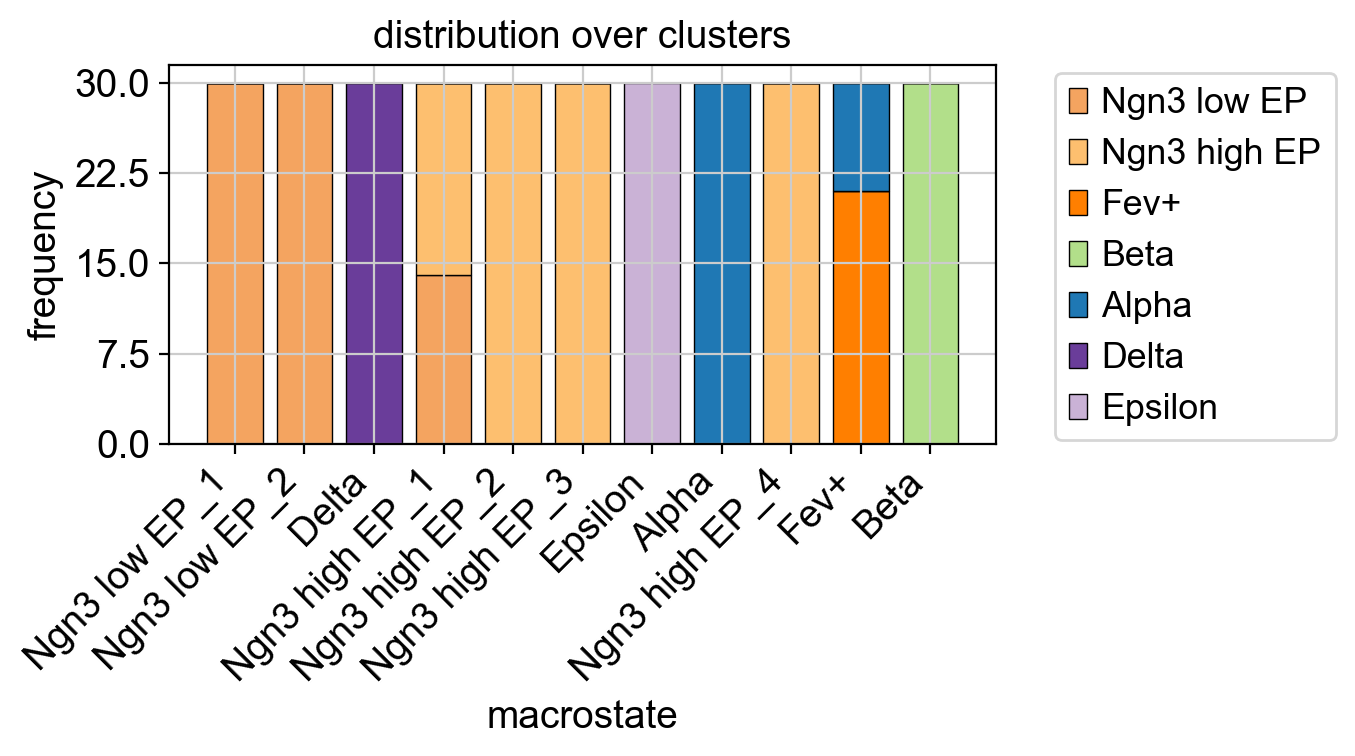

In [10]:
g.plot_macrostate_composition(key="clusters", figsize=(7, 4))

With some exceptions, most macrostates recruit their top-cells from a single underlying cluster. This plotting function works for any observation-level covariate and can be useful when we have experimental time labels as we expect more mature states to come from later time points. See the {class}`~cellrank.kernels.RealTimeKernel` and the corresponding {doc}`tutorial <../kernels/500_real_time>` to learn how CellRank makes use of experimental time points. 

To get an idea of how these macrostates are related, we plot the {attr}`coarse-grained transition matrix <cellrank.estimators.GPCCA.coarse_T>`. 

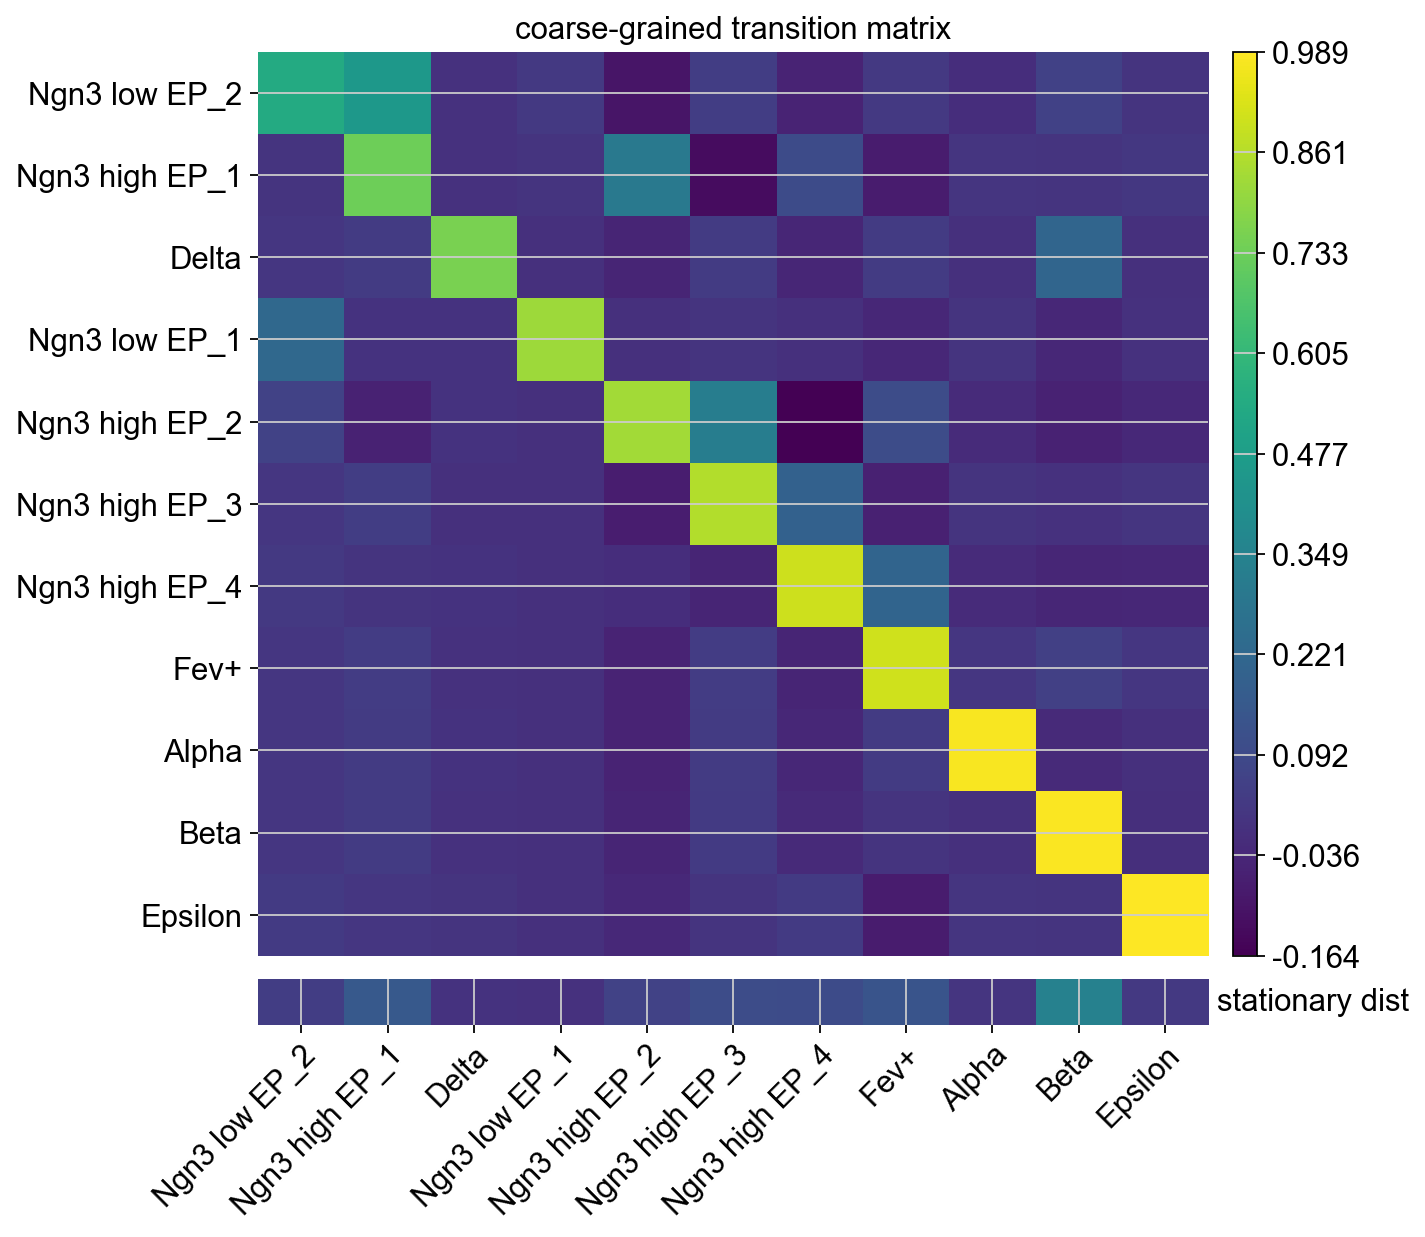

In [11]:
g.plot_coarse_T(annotate=False)

By default, macrostates are ordered according to their diagonal value, increasing from left to right. The diagonal value is a proxy for a states' *metastability*, i.e. the probability of leaving the state once entered. While the Epsilon, Alpha and Beta states have high diagonal values, Delta cells have a low value because they are predicted to transition into Beta cells (check the corresponding matrix element). 

### Classify macrostates

Let's try automatic terminal state identification first. 

INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                                                                 
                `.terminal_states_probabilities`                                                                   
                `.terminal_states_memberships                                                                      
             Finish`                                                                                               


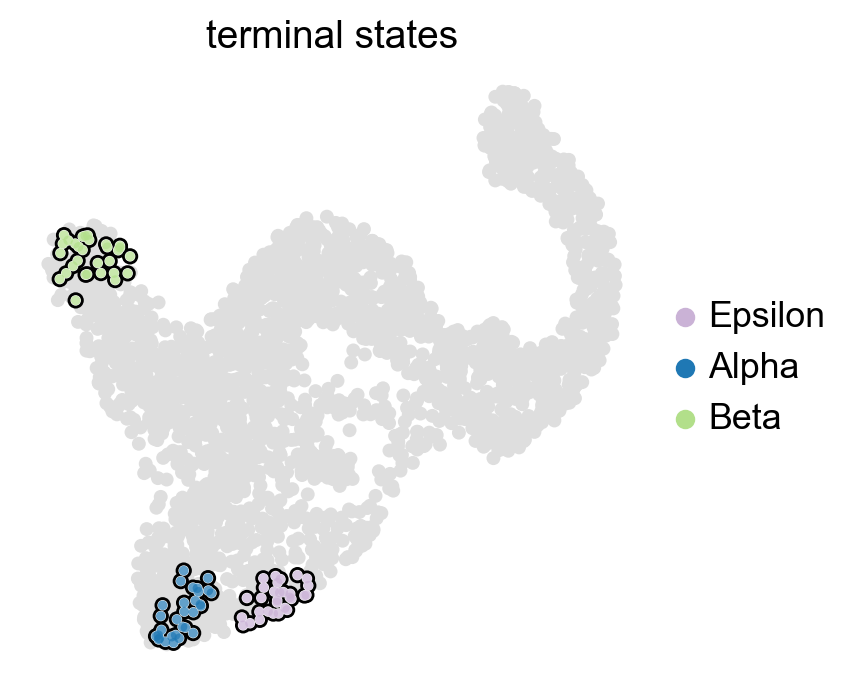

In [12]:
g.predict_terminal_states()
g.plot_macrostates(which="terminal", legend_loc="right", s=100)

We can visually confirm our terminal state identification by comparing with well-known mature cell-type markers *Ins1* and *Ins2* for Beta cells, *Gcg* for Alpha cells and *Ghrl* for epsilon cells. 

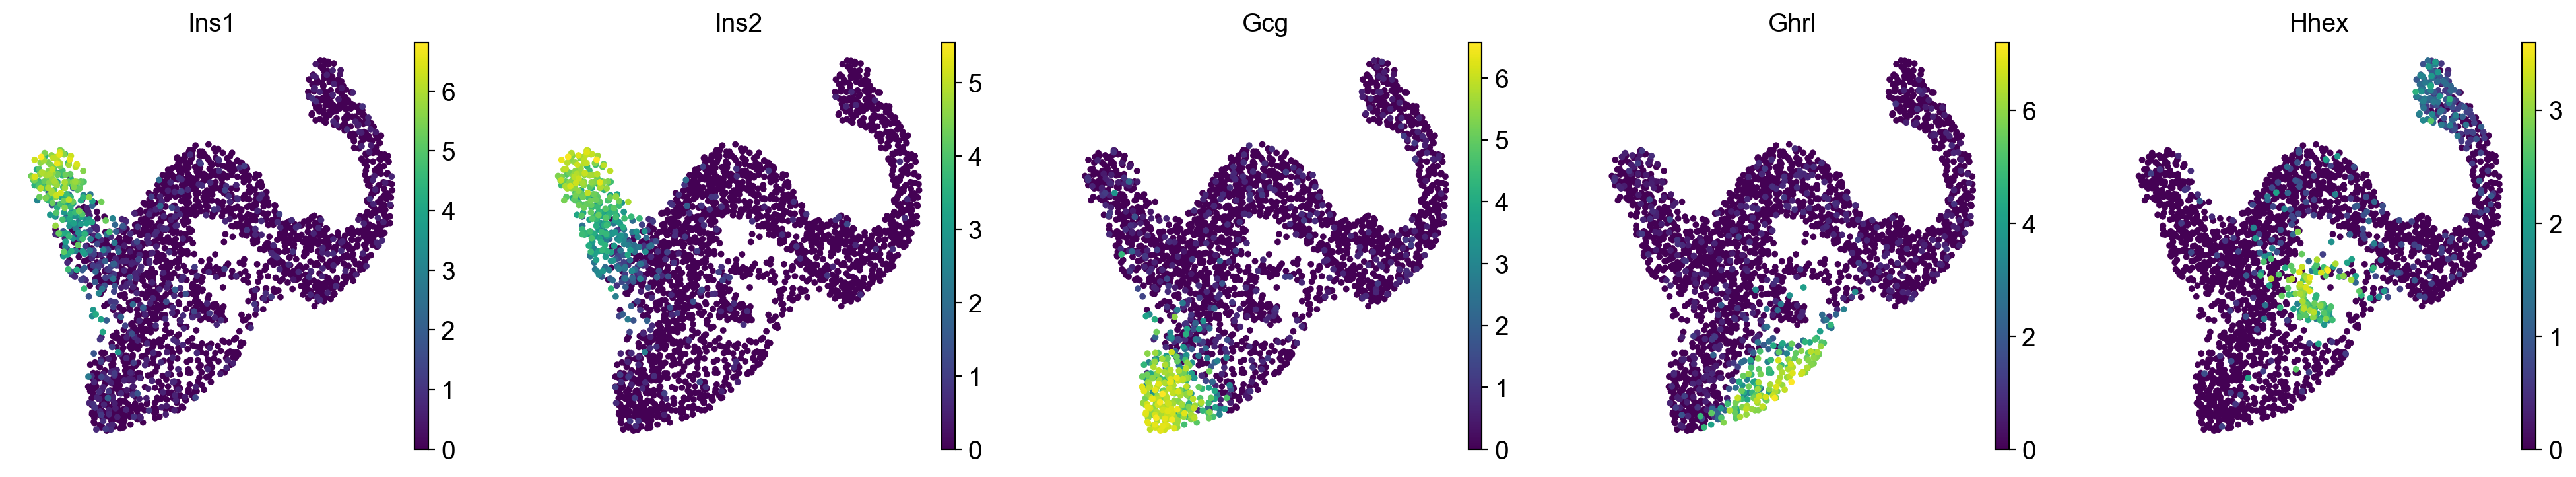

In [13]:
sc.pl.embedding(
    adata,
    basis="umap",
    color=["Ins1", "Ins2", "Gcg", "Ghrl", "Hhex"],
    ncols=5,
    size=50,
)

We correctly identified some hormone-producing terminal cell states. However, we did not catch the Delta cells (marked by *Hhex*)! If we want to compute {attr}`fate probabilities <cellrank.estimators.GPCCA.fate_probabilities>` towards them later on, we need to annotate them as a terminal state. Luckily, this can be done semi-automatically as well:

INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                                                                 
                `.terminal_states_probabilities`                                                                   
                `.terminal_states_memberships                                                                      
             Finish`                                                                                               


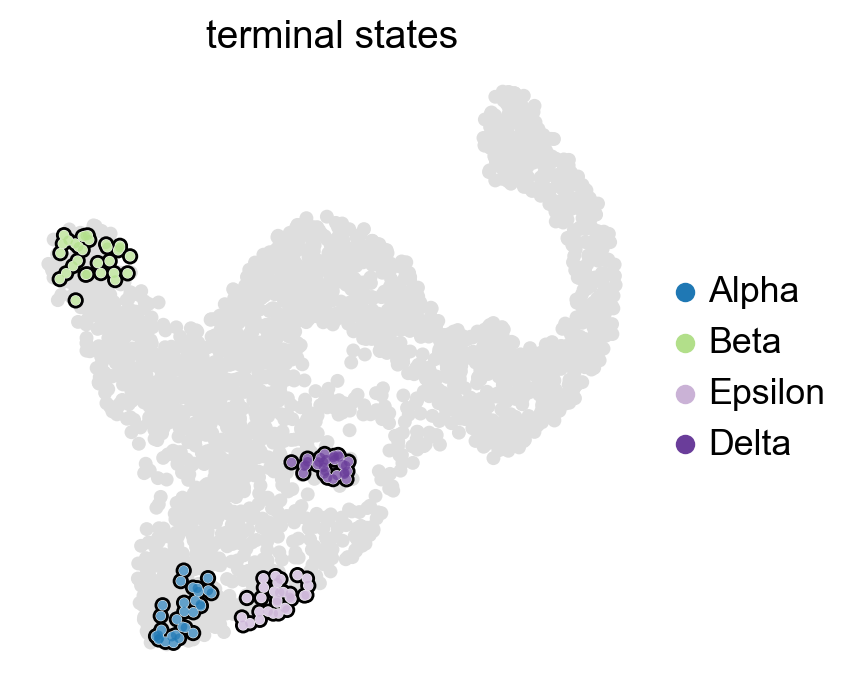

In [14]:
g.set_terminal_states(states=["Alpha", "Beta", "Epsilon", "Delta"])
g.plot_macrostates(which="terminal", legend_loc="right", s=100)

We call this semi-automatic terminal state identification as we manually pass the macrostates we would like to select, however, the actual cells belonging to each macrostate are assigned automatically. For initial states, everything works exactly the same, you can identify them fully automatically, or semi-automatically. Let's compute the initial states fully automatically here: 

INFO     Adding `adata.obs['init_states_fwd']`                                                                     
                `adata.obs['init_states_fwd_probs']`                                                               
                `.initial_states`                                                                                  
                `.initial_states_probabilities`                                                                    
                `.initial_states_memberships                                                                       
             Finish`                                                                                               


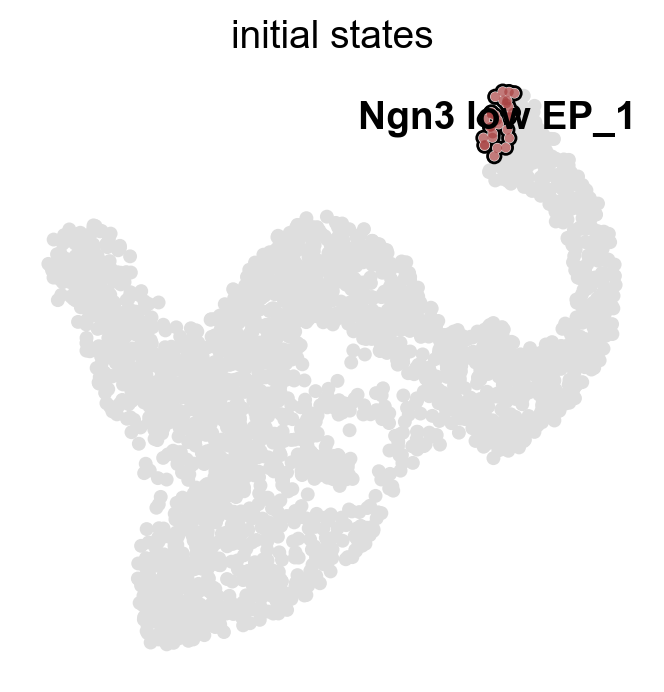

In [15]:
g.predict_initial_states()
g.plot_macrostates(which="initial", s=100)

How can we check whether this is really the correct initial state? In this case, we have prior knowledge that we can use: we know that the initial state should be high for a number of Ductal cell markers. So let's use these markers to compute a score that we can visualize across macrostates to confirm that we have the correct one. 

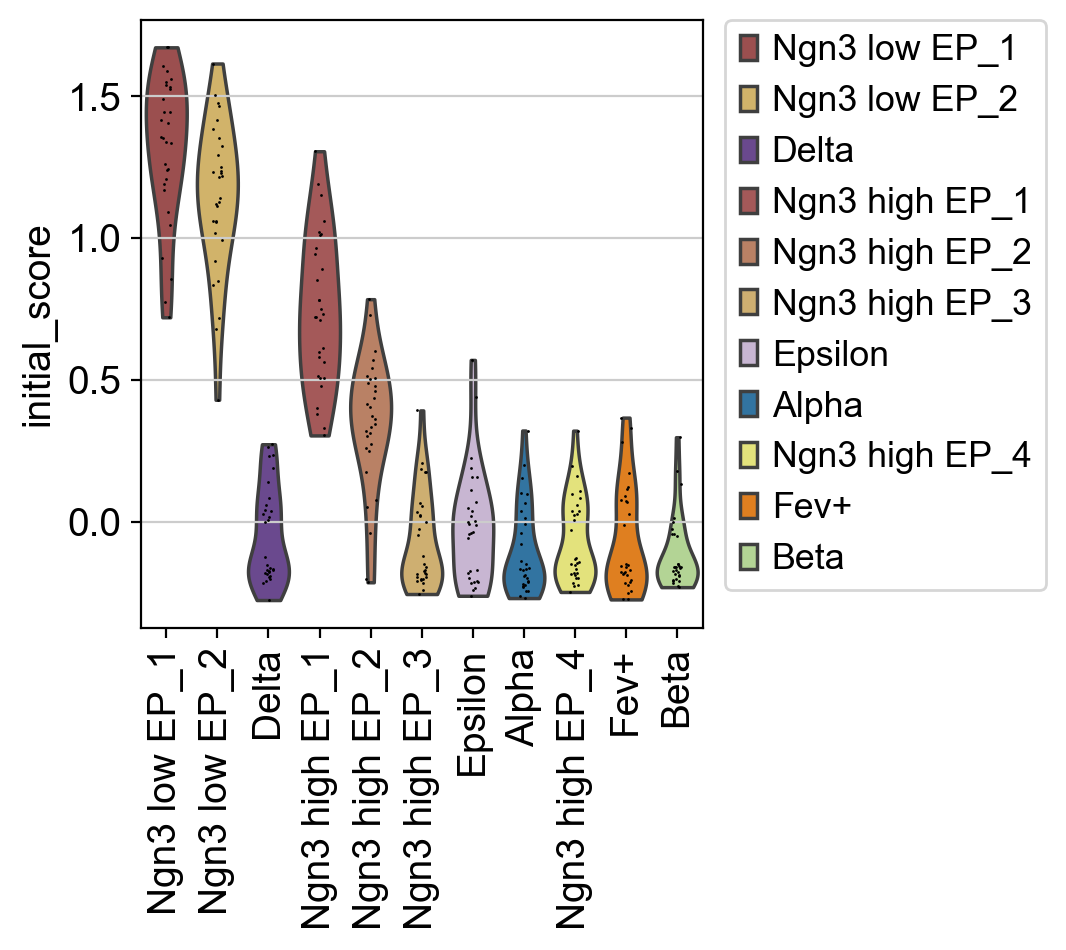

In [16]:
# compute a score in scanpy by aggregating across a few ductal markers
sc.tl.score_genes(
    adata, gene_list=["Bicc1", "Sox9", "Anxa2"], score_name="initial_score"
)

# write macrostates to AnnData
adata.obs["macrostates"] = g.macrostates
adata.uns["macrostates_colors"] = g.macrostates_memberships.colors

# visualize
ax = sc.pl.violin(
    adata, keys="initial_score", groupby="macrostates", rotation=90, show=False
)
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

In fact, the `'Ngn3 low EP_1'` state scores highest, confirming the identification of this state as as initial state. The same strategy can be used to confirm terminal state identification, or to guide semi-automatic identification in the first place. 

## Closing matters

### What's next? 

In this tutorial, you learned how to use CellRank's {class}`GPCCA estimator <cellrank.estimators.GPCCA>` to compute initial and terminal states of cellular dynamics. For the next steps, we recommend to: 

- go through the {doc}`fate probabilities & driver genes tutorial <700_fate_probabilities>` to learn how to quantify cellular fate commitment. 
- take a look at the {class}`API <cellrank.estimators.GPCCA>` to learn about parameter values you can use to adapt these computations to your data. 
-  read the original GPCCA publications to get familiar with the maths and ideas behind these computations {cite}`reuter:18, reuter:19`. 

### Package versions

In [17]:
session_info2.session_info()

Package,Version
cellrank,2.1.1.dev34+g4fc55ac4f.d20260305
scanpy,1.12
matplotlib,3.10.8
anndata,0.12.10
Component,Info
Python,"3.12.12 | packaged by conda-forge | (main, Jan 27 2026, 00:01:15) [Clang 19.1.7 ]"
OS,macOS-26.3-arm64-arm-64bit
Updated,2026-03-05 07:16
Dependency,Version
natsort,8.4.0
